# Multi-Task Needs Model

We train a multi-task MLP to predict, per client, the probability of holding
an *Accumulation* need and/or an *Income* need. The network is then
calibrated and plugged into a MiFID-compliant Next-Best-Action engine.

**Label caveat.** `IncomeInvestment` and `AccumulationInvestment` are revealed
preferences — a client is labelled as having a need only if a
professionally-vetted advisor matched them with a satisfying product. Two
consequences that shape the modelling choices:

1. **Label noise** — the model can only be as good as the advisor process it
   clones. The KL consistency term in the loss anchors the model on the
   aggregate behaviour of the advisor pool rather than overfitting individual
   calls.
2. **Selection bias** — some `y = 0` clients may in fact have the need; the
   advisor just didn't act on it. This biases recall downward, so we read
   precision-oriented metrics with care and will want post-recommendation
   acceptance data in production.


In [13]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.optim as optim
from torch.utils.data import DataLoader

from NN.features     import clean_and_engineer, prepare_model_data, FAT_TAIL_FEATURES
from NN.dataset      import FinancialNeedsDataset
from NN.model        import MultiTaskNeedsMLP
from NN.train        import train_multitask_model

Path('artifacts').mkdir(exist_ok=True)

# Load, engineer, split. The split is strict 3-way (train / val / test);
# scalers are fit on TRAIN only and returned so that inference at prediction
# time applies the exact same transform.
df            = pd.read_excel('Dataset2_Needs.xls', sheet_name='Needs')
df_engineered = clean_and_engineer(df)

(X_train, X_val, X_test,
 y_train, y_val, y_test,
 feature_cols, qt, rs) = prepare_model_data(df_engineered)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
joblib.dump({'qt': qt, 'rs': rs, 'feature_cols': feature_cols},
            'artifacts/preprocessors.joblib')

# Discrete columns are excluded from noise augmentation: a Gaussian
# perturbation on FamilyMembers creates impossible users (e.g. 2.3 members).
discrete_features = {
    'Gender', 'FamilyMembers', 'FinancialEducation',
    'LifeStage_working', 'LifeStage_retired',
}
continuous_mask = [col not in discrete_features for col in feature_cols]

# The final hyperparameter search chose augment=False; we keep the mask around
# because the ablation study still exercises augment=True as a comparison.
train_dataset = FinancialNeedsDataset(X_train, y_train, augment=False)
val_dataset   = FinancialNeedsDataset(X_val,   y_val,   augment=False)
test_dataset  = FinancialNeedsDataset(X_test,  y_test,  augment=False)

train_loader = DataLoader(train_dataset, batch_size=64,  shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)


Train: (3200, 20) | Val: (800, 20) | Test: (1000, 20)


In [14]:
# pos_weight for each head: ratio of negatives to positives in TRAIN.
# This is the standard BCEWithLogitsLoss knob for imbalanced binary targets.
num_acc_pos = y_train['AccumulationInvestment'].sum()
num_inc_pos = y_train['IncomeInvestment'].sum()
w_a = torch.tensor((len(y_train) - num_acc_pos) / num_acc_pos, dtype=torch.float32)
w_i = torch.tensor((len(y_train) - num_inc_pos) / num_inc_pos, dtype=torch.float32)
print(f"Class weight Accumulation: {w_a.item():.3f} | Income: {w_i.item():.3f}")

# Empirical joint distribution over the four segments, estimated on TRAIN.
# The KL term in the loss drags each batch's implied joint towards this prior.
ya = y_train['AccumulationInvestment'].values
yi = y_train['IncomeInvestment'].values
joint_prior = torch.tensor([
    ((1 - ya) * (1 - yi)).mean(),     # Neither
    ((1 - ya) *      yi ).mean(),     # Income only
    (     ya  * (1 - yi)).mean(),     # Accumulation only
    (     ya  *      yi ).mean(),     # Both
], dtype=torch.float32)
print(f"Empirical joint prior (Neither, IncOnly, AccOnly, Both): "
      f"{joint_prior.numpy().round(3)}")


Class weight Accumulation: 0.949 | Income: 1.606
Empirical joint prior (Neither, IncOnly, AccOnly, Both): [0.303 0.184 0.313 0.2  ]


## Hyperparameter tuning

We run a TPE search over learning rate, weight decay, dropout, trunk widths,
KL penalty, and batch size. The objective is the mean validation PR-AUC
across the two heads — the right signal for an imbalanced classification
problem. Each trial is capped at 40 epochs with early-stopping patience 10.

Set `RUN_OPTUNA = False` to skip the search and fall back to the defaults.


In [15]:
import optuna
from optuna.samplers import TPESampler
from sklearn.metrics import average_precision_score

RUN_OPTUNA = True
N_TRIALS   = 50

def objective(trial):
    lr         = trial.suggest_float('lr',            1e-4, 5e-3, log=True)
    wd         = trial.suggest_float('weight_decay',  1e-6, 1e-3, log=True)
    dropout_p  = trial.suggest_float('dropout',       0.10, 0.45)
    trunk_w1   = trial.suggest_categorical('trunk_w1', [32, 64, 96, 128])
    trunk_w2   = trial.suggest_categorical('trunk_w2', [16, 32, 48, 64])
    head_w     = trial.suggest_categorical('head_w',   [8, 16, 24, 32])
    lam        = trial.suggest_float('lam', 0.0, 0.30)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])

    # Augmentation is kept off here: a preliminary ablation showed it hurts.
    ds = FinancialNeedsDataset(X_train, y_train, augment=False)
    ld = DataLoader(ds, batch_size=batch_size, shuffle=True)

    torch.manual_seed(42)
    m = MultiTaskNeedsMLP(in_dim=len(feature_cols),
                          trunk=(trunk_w1, trunk_w2),
                          head=(head_w,),
                          p=dropout_p)
    opt = optim.AdamW(m.parameters(), lr=lr, weight_decay=wd)

    try:
        m, _ = train_multitask_model(m, ld, val_loader, opt,
                                     w_a, w_i, joint_prior,
                                     epochs=40, patience=10, lam=lam)
    except Exception:
        raise optuna.TrialPruned()           # NaN losses / degenerate configs

    # Mean validation PR-AUC across the two heads
    m.eval()
    pa, pi, ya, yi = [], [], [], []
    with torch.no_grad():
        for X_batch, y_inc_b, y_acc_b in val_loader:
            la, li = m(X_batch)
            pa.extend(torch.sigmoid(la).numpy())
            pi.extend(torch.sigmoid(li).numpy())
            ya.extend(y_acc_b.numpy())
            yi.extend(y_inc_b.numpy())
    return 0.5 * (average_precision_score(ya, pa) +
                  average_precision_score(yi, pi))


if RUN_OPTUNA:
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='maximize',
                                sampler=TPESampler(seed=42))
    print(f"Running Optuna ({N_TRIALS} trials)...")
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    print(f"\nBest mean PR-AUC: {study.best_value:.4f}")
    for k, v in study.best_params.items():
        print(f"  {k}: {v}")

    BEST = study.best_params
else:
    BEST = dict(lr=1e-3, weight_decay=1e-4, dropout=0.25,
                trunk_w1=64, trunk_w2=32, head_w=16,
                lam=0.15, batch_size=64)
    print("Skipped Optuna. Using fallback defaults:", BEST)

joblib.dump(BEST, 'artifacts/best_hyperparams.joblib')

# Rebuild the production model + loader with the winning config
train_loader = DataLoader(
    FinancialNeedsDataset(X_train, y_train, augment=False),
    batch_size=BEST['batch_size'], shuffle=True,
)
model = MultiTaskNeedsMLP(
    in_dim=len(feature_cols),
    trunk=(BEST['trunk_w1'], BEST['trunk_w2']),
    head=(BEST['head_w'],),
    p=BEST['dropout'],
)
optimizer = optim.AdamW(model.parameters(),
                        lr=BEST['lr'], weight_decay=BEST['weight_decay'])


Running Optuna (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 000 | Loss: 1.5354 | ROC-AUC (Acc/Inc): 0.671/0.685 | PR-AUC (Acc/Inc): 0.653/0.632
Epoch 010 | Loss: 1.3077 | ROC-AUC (Acc/Inc): 0.806/0.710 | PR-AUC (Acc/Inc): 0.827/0.698
Epoch 020 | Loss: 1.2500 | ROC-AUC (Acc/Inc): 0.825/0.717 | PR-AUC (Acc/Inc): 0.862/0.703
Epoch 030 | Loss: 1.2272 | ROC-AUC (Acc/Inc): 0.841/0.724 | PR-AUC (Acc/Inc): 0.882/0.708
Epoch 000 | Loss: 1.3959 | ROC-AUC (Acc/Inc): 0.777/0.705 | PR-AUC (Acc/Inc): 0.772/0.692
Epoch 010 | Loss: 1.1498 | ROC-AUC (Acc/Inc): 0.856/0.724 | PR-AUC (Acc/Inc): 0.892/0.708
Epoch 020 | Loss: 1.1168 | ROC-AUC (Acc/Inc): 0.859/0.736 | PR-AUC (Acc/Inc): 0.895/0.714
Epoch 030 | Loss: 1.1207 | ROC-AUC (Acc/Inc): 0.860/0.733 | PR-AUC (Acc/Inc): 0.896/0.713
Epoch 000 | Loss: 1.4215 | ROC-AUC (Acc/Inc): 0.805/0.700 | PR-AUC (Acc/Inc): 0.802/0.688
Epoch 010 | Loss: 1.1366 | ROC-AUC (Acc/Inc): 0.861/0.736 | PR-AUC (Acc/Inc): 0.896/0.713
Epoch 020 | Loss: 1.1185 | ROC-AUC (Acc/Inc): 0.865/0.745 | PR-AUC (Acc/Inc): 0.898/0.721
Epoch 030 

In [16]:
print("Training multi-task model on the tuned config...\n")

best_model, val_prauc = train_multitask_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    w_a=w_a, w_i=w_i,
    joint_prior=joint_prior,
    epochs=150,
    patience=20,
    lam=BEST['lam'],
)
print(f"\nBest validation mean PR-AUC: {val_prauc:.4f}")


Training multi-task model on the tuned config...

Epoch 000 | Loss: 1.3415 | ROC-AUC (Acc/Inc): 0.797/0.713 | PR-AUC (Acc/Inc): 0.784/0.697
Epoch 010 | Loss: 1.1062 | ROC-AUC (Acc/Inc): 0.864/0.720 | PR-AUC (Acc/Inc): 0.898/0.705
Epoch 020 | Loss: 1.0965 | ROC-AUC (Acc/Inc): 0.867/0.727 | PR-AUC (Acc/Inc): 0.899/0.715
Epoch 030 | Loss: 1.0807 | ROC-AUC (Acc/Inc): 0.861/0.726 | PR-AUC (Acc/Inc): 0.896/0.714
Epoch 040 | Loss: 1.0655 | ROC-AUC (Acc/Inc): 0.871/0.732 | PR-AUC (Acc/Inc): 0.903/0.719
Epoch 050 | Loss: 1.0564 | ROC-AUC (Acc/Inc): 0.873/0.731 | PR-AUC (Acc/Inc): 0.906/0.718
Epoch 060 | Loss: 1.0462 | ROC-AUC (Acc/Inc): 0.870/0.731 | PR-AUC (Acc/Inc): 0.902/0.720
Epoch 070 | Loss: 1.0364 | ROC-AUC (Acc/Inc): 0.866/0.740 | PR-AUC (Acc/Inc): 0.900/0.727
Epoch 080 | Loss: 1.0083 | ROC-AUC (Acc/Inc): 0.870/0.734 | PR-AUC (Acc/Inc): 0.904/0.727

Early stopping triggered at epoch 83. Restoring best weights.

Best validation mean PR-AUC: 0.8201


## Calibration and final test evaluation

The raw sigmoid outputs are not well-calibrated because training uses
`pos_weight` to fight class imbalance. We fit a 2-parameter Platt scaler
per head on the validation set, keep it only if it actually improves Brier
score, then freeze the calibrators and the F1-optimal thresholds before
touching the test set.


In [17]:
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             brier_score_loss, classification_report)

from NN.calibration import get_raw_probs, fit_calibrator, best_threshold

# Fit calibrators on VAL probabilities, per head
p_acc_val, p_inc_val, y_acc_val, y_inc_val = get_raw_probs(model, val_loader)

print("Fitting calibrators on validation set:")
cal_acc, lr_acc, acc_kept = fit_calibrator(p_acc_val, y_acc_val, "Accumulation")
cal_inc, lr_inc, inc_kept = fit_calibrator(p_inc_val, y_inc_val, "Income      ")

p_acc_val_cal = cal_acc(p_acc_val)
p_inc_val_cal = cal_inc(p_inc_val)

# F1-optimal decision threshold, per head, on VAL
thr_acc, f1_acc_val = best_threshold(y_acc_val, p_acc_val_cal)
thr_inc, f1_inc_val = best_threshold(y_inc_val, p_inc_val_cal)
print(f"\nOptimal thresholds | Accum: {thr_acc:.3f} (F1={f1_acc_val:.3f}) "
      f"| Income: {thr_inc:.3f} (F1={f1_inc_val:.3f})")

# Now apply the frozen calibrators + thresholds to TEST
p_acc_te, p_inc_te, y_acc_te, y_inc_te = get_raw_probs(model, test_loader)
p_acc_te_cal = cal_acc(p_acc_te)
p_inc_te_cal = cal_inc(p_inc_te)

print("\n=== HOLD-OUT TEST RESULTS ===")
for name, y_te, p_raw, p_cal, thr in [
    ('Accumulation', y_acc_te, p_acc_te, p_acc_te_cal, thr_acc),
    ('Income',       y_inc_te, p_inc_te, p_inc_te_cal, thr_inc),
]:
    print(f"\n--- {name} ---")
    print(f"ROC-AUC:       {roc_auc_score(y_te, p_cal):.4f}")
    print(f"PR-AUC:        {average_precision_score(y_te, p_cal):.4f}")
    print(f"Brier (raw):   {brier_score_loss(y_te, p_raw):.4f}")
    print(f"Brier (calib): {brier_score_loss(y_te, p_cal):.4f}")
    print(classification_report(y_te, (p_cal > thr).astype(int), digits=3))

# Persist calibrators, thresholds, and model weights for production
joblib.dump({'lr_acc': lr_acc, 'acc_kept': acc_kept,
             'lr_inc': lr_inc, 'inc_kept': inc_kept,
             'thr_acc': thr_acc, 'thr_inc': thr_inc},
            'artifacts/calibration.joblib')
torch.save(model.state_dict(), 'artifacts/model_weights.pt')

# Save test probabilities + labels for the cross-model comparison notebook
Path('compare_preds').mkdir(exist_ok=True)
np.save('compare_preds/y_acc_test.npy',     y_acc_te)
np.save('compare_preds/y_inc_test.npy',     y_inc_te)
np.save('compare_preds/mtl_p_acc_test.npy', p_acc_te_cal)
np.save('compare_preds/mtl_p_inc_test.npy', p_inc_te_cal)
print("\nMTL test predictions saved to compare_preds/")


Fitting calibrators on validation set:
  Accumulation: calibration KEPT    (Brier 0.1353 -> 0.1349)
  Income      : calibration KEPT    (Brier 0.1833 -> 0.1775)

Optimal thresholds | Accum: 0.480 (F1=0.809) | Income: 0.405 (F1=0.651)

=== HOLD-OUT TEST RESULTS ===

--- Accumulation ---
ROC-AUC:       0.8504
PR-AUC:        0.8911
Brier (raw):   0.1462
Brier (calib): 0.1486
              precision    recall  f1-score   support

         0.0      0.763     0.832     0.796       487
         1.0      0.825     0.754     0.788       513

    accuracy                          0.792      1000
   macro avg      0.794     0.793     0.792      1000
weighted avg      0.795     0.792     0.792      1000


--- Income ---
ROC-AUC:       0.7926
PR-AUC:        0.7856
Brier (raw):   0.1616
Brier (calib): 0.1589
              precision    recall  f1-score   support

         0.0      0.784     0.896     0.837       617
         1.0      0.783     0.603     0.681       383

    accuracy                  

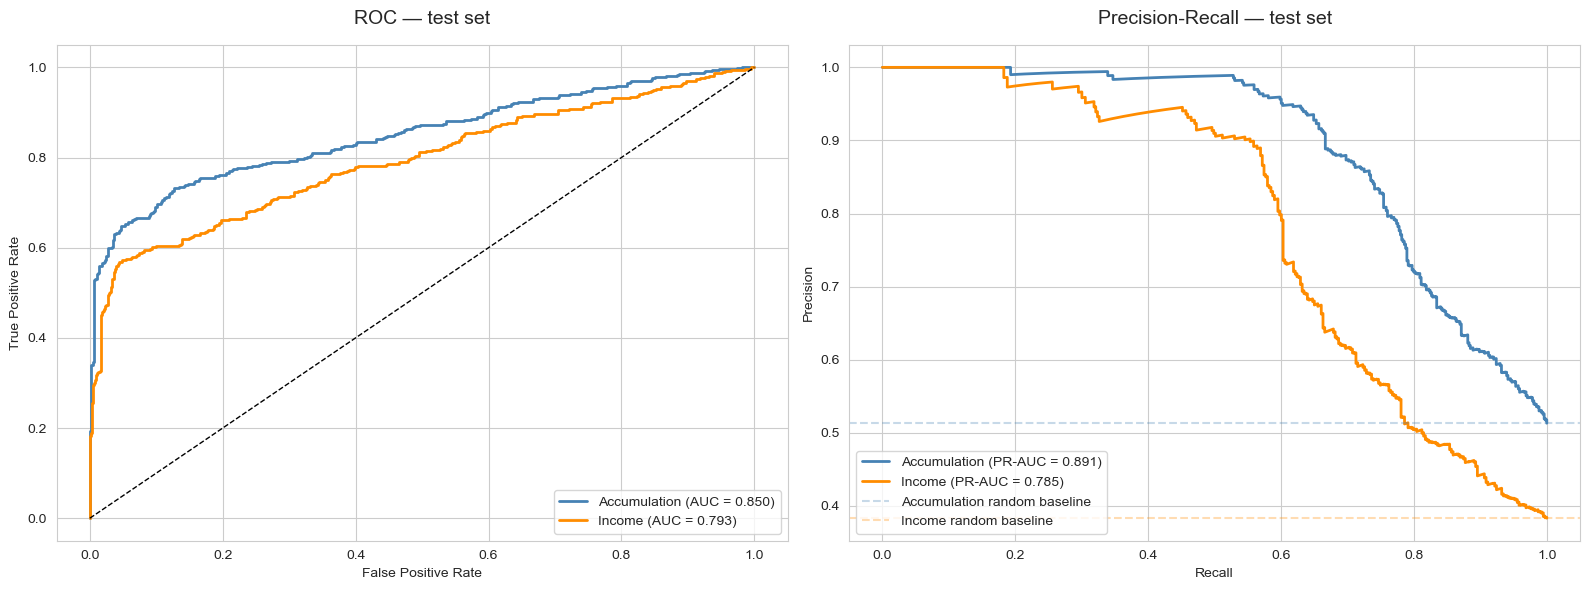

In [18]:
from NN.evaluate import plot_test_curves

plot_test_curves(y_acc_te, p_acc_te_cal, y_inc_te, p_inc_te_cal)


## Explainability

Two complementary views of what the model learned:

* **SHAP (DeepExplainer)** — local and global attribution via background
  sampling. Per head, because our model has a tuple output.
* **Permutation importance** — model-agnostic, directly comparable to the
  Random Forest baseline, and measures the quantity that matters at
  inference: drop in PR-AUC when a column is shuffled.


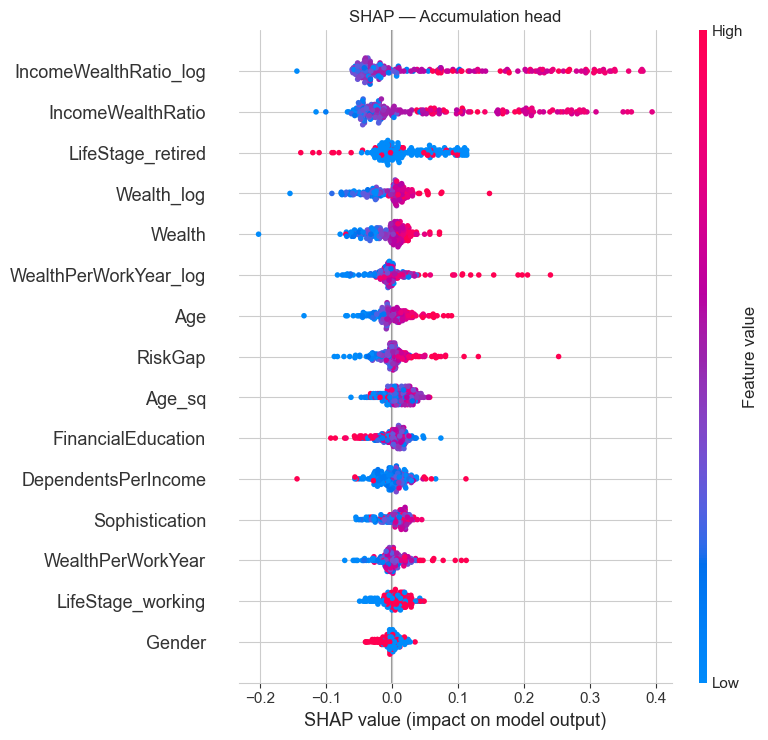

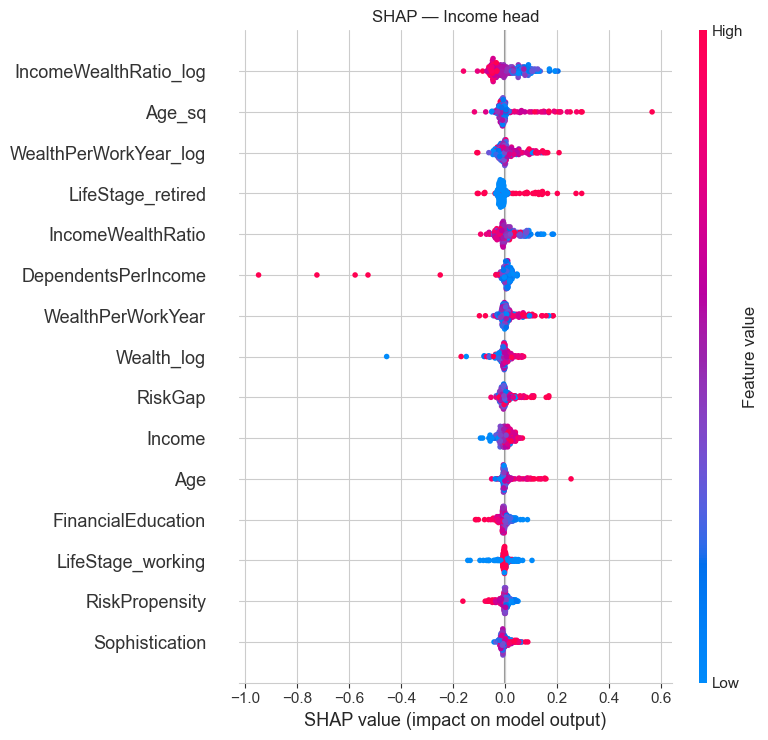

In [19]:
from NN.explain import shap_per_head

shap_per_head(model, X_train.values, X_test.values,
              feature_names=feature_cols, head_name='accum',
              title='SHAP — Accumulation head')

shap_per_head(model, X_train.values, X_test.values,
              feature_names=feature_cols, head_name='income',
              title='SHAP — Income head')


Computing permutation importance on the TEST set (~30s)...
Baseline PR-AUC  |  Accumulation: 0.8911   Income: 0.7856


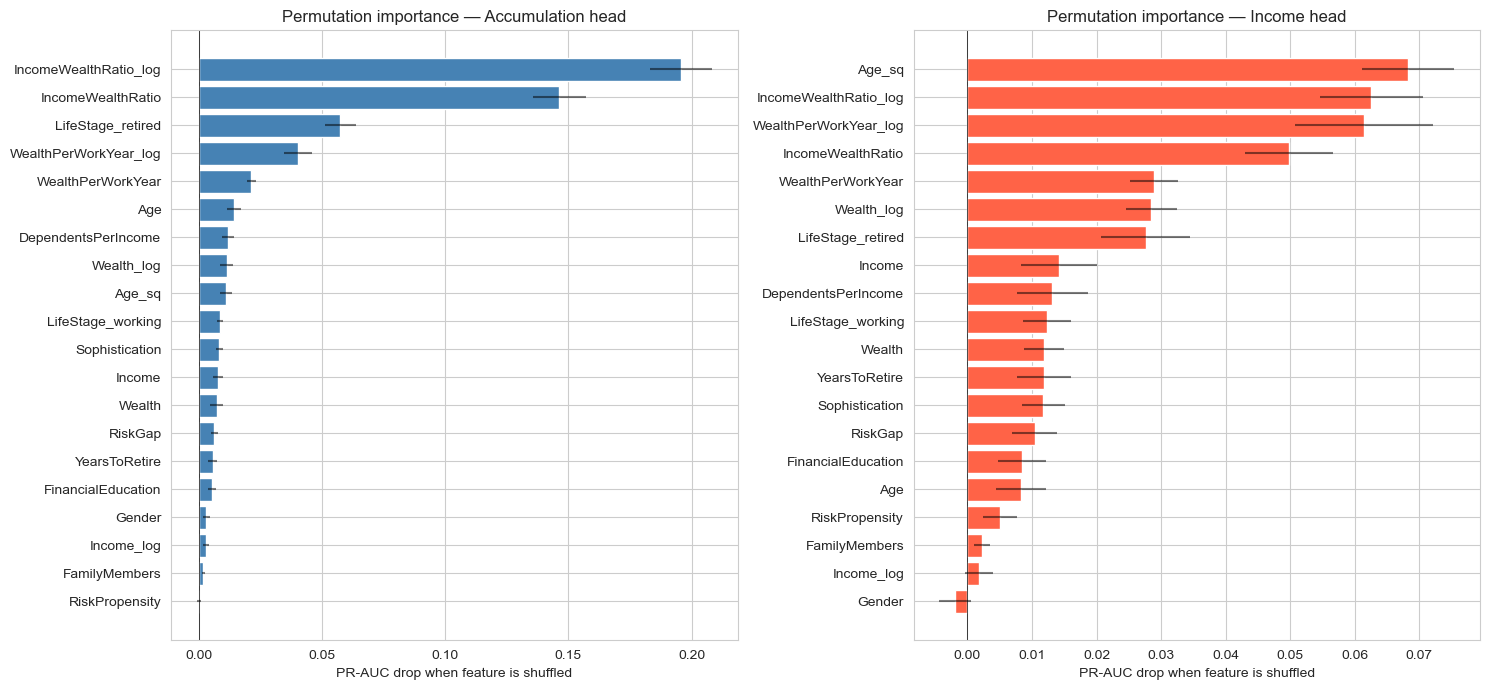


Accumulation head, top 5 drivers:
              feature  mean_drop  std_drop
IncomeWealthRatio_log   0.195705  0.012449
    IncomeWealthRatio   0.146234  0.010714
    LifeStage_retired   0.057375  0.006281
WealthPerWorkYear_log   0.040264  0.005571
    WealthPerWorkYear   0.021327  0.001863

Income head, top 5 drivers:
              feature  mean_drop  std_drop
               Age_sq   0.068280  0.007128
IncomeWealthRatio_log   0.062587  0.007983
WealthPerWorkYear_log   0.061436  0.010733
    IncomeWealthRatio   0.049825  0.006778
    WealthPerWorkYear   0.028968  0.003711

Features with drop < 0.001 on BOTH heads (removal candidates):
  (none found)


In [20]:
from NN.explain import permutation_importance_nn, plot_permutation_importance

print("Computing permutation importance on the TEST set (~30s)...")
y_acc_te_arr = y_test['AccumulationInvestment'].values
y_inc_te_arr = y_test['IncomeInvestment'].values

perm_acc, perm_inc, base_acc, base_inc = permutation_importance_nn(
    model, X_test, y_acc_te_arr, y_inc_te_arr, feature_cols, n_repeats=10,
)
print(f"Baseline PR-AUC  |  Accumulation: {base_acc:.4f}   Income: {base_inc:.4f}")

plot_permutation_importance(perm_acc, perm_inc)

print("\nAccumulation head, top 5 drivers:")
print(perm_acc.head().to_string(index=False))
print("\nIncome head, top 5 drivers:")
print(perm_inc.head().to_string(index=False))

# Candidate "dead" features: a drop below 0.1% PR-AUC is noise. If a feature
# is noise on BOTH heads we'll consider retraining without it.
DEAD_THRESHOLD = 0.001
dead_features = []
for f in feature_cols:
    drop_acc = perm_acc.loc[perm_acc['feature'] == f, 'mean_drop'].iloc[0]
    drop_inc = perm_inc.loc[perm_inc['feature'] == f, 'mean_drop'].iloc[0]
    if drop_acc < DEAD_THRESHOLD and drop_inc < DEAD_THRESHOLD:
        dead_features.append(f)

print(f"\nFeatures with drop < {DEAD_THRESHOLD} on BOTH heads (removal candidates):")
if dead_features:
    for f in dead_features:
        da = perm_acc.loc[perm_acc['feature'] == f, 'mean_drop'].iloc[0]
        di = perm_inc.loc[perm_inc['feature'] == f, 'mean_drop'].iloc[0]
        print(f"  {f:28s}  Acc drop: {da:+.4f}   Inc drop: {di:+.4f}")
else:
    print("  (none found)")


## Ablation: where does the gain come from?

Four variants, same capacity, same seed, validation-only metrics:

1. Single-task — two independent networks, no shared trunk, no KL
2. Multi-task, no KL, no augmentation — shared trunk only
3. Multi-task, KL, no augmentation — adds the joint-distribution penalty
4. Multi-task, KL + augmentation — adds Gaussian noise on continuous features


Running ablation...

Epoch 000 | Loss: 1.4559 | ROC-AUC (Acc/Inc): 0.706/0.699 | PR-AUC (Acc/Inc): 0.695/0.688
Epoch 010 | Loss: 1.1551 | ROC-AUC (Acc/Inc): 0.855/0.734 | PR-AUC (Acc/Inc): 0.892/0.713
Epoch 020 | Loss: 1.1389 | ROC-AUC (Acc/Inc): 0.858/0.732 | PR-AUC (Acc/Inc): 0.895/0.712
Epoch 030 | Loss: 1.1234 | ROC-AUC (Acc/Inc): 0.859/0.740 | PR-AUC (Acc/Inc): 0.895/0.718
Epoch 040 | Loss: 1.1114 | ROC-AUC (Acc/Inc): 0.863/0.745 | PR-AUC (Acc/Inc): 0.899/0.721
Epoch 050 | Loss: 1.0948 | ROC-AUC (Acc/Inc): 0.862/0.743 | PR-AUC (Acc/Inc): 0.897/0.721
Epoch 060 | Loss: 1.0944 | ROC-AUC (Acc/Inc): 0.865/0.748 | PR-AUC (Acc/Inc): 0.900/0.722
Epoch 070 | Loss: 1.0843 | ROC-AUC (Acc/Inc): 0.864/0.739 | PR-AUC (Acc/Inc): 0.900/0.721

Early stopping triggered at epoch 78. Restoring best weights.
Epoch 000 | Loss: 1.4578 | ROC-AUC (Acc/Inc): 0.706/0.699 | PR-AUC (Acc/Inc): 0.695/0.688
Epoch 010 | Loss: 1.1558 | ROC-AUC (Acc/Inc): 0.855/0.734 | PR-AUC (Acc/Inc): 0.892/0.713
Epoch 020 | Loss

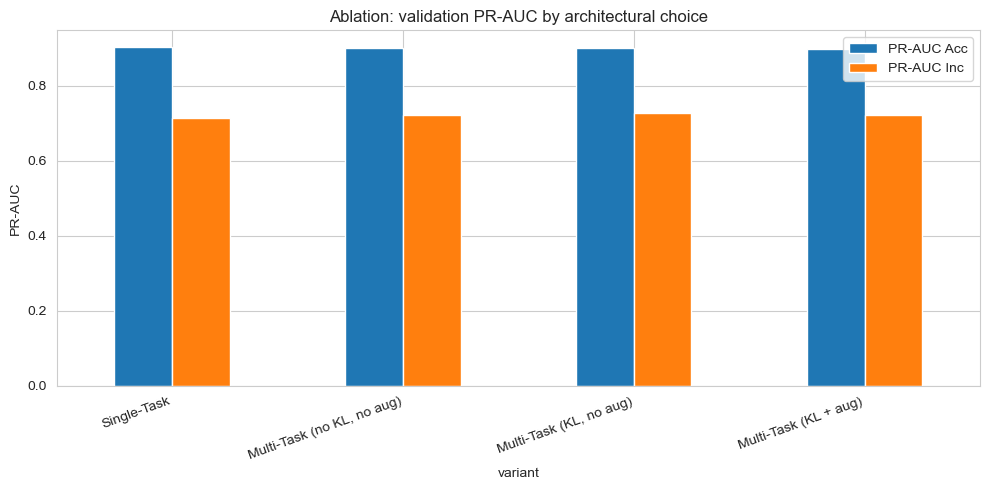

In [21]:
import matplotlib.pyplot as plt
from NN.ablation import Variant, run_variant

variants = [
    Variant('Single-Task',                False, False, False),
    Variant('Multi-Task (no KL, no aug)',  True,  False, False),
    Variant('Multi-Task (KL, no aug)',     True,  True,  False),
    Variant('Multi-Task (KL + aug)',       True,  True,  True),
]

print("Running ablation...\n")
results = [
    run_variant(v, X_train, y_train, X_val, y_val, val_loader,
                feature_cols, continuous_mask,
                w_a, w_i, joint_prior)
    for v in variants
]
abl_df = pd.DataFrame(results).set_index('variant').round(4)
print(abl_df)

abl_df[['PR-AUC Acc', 'PR-AUC Inc']].plot(kind='bar', figsize=(10, 5))
plt.title('Ablation: validation PR-AUC by architectural choice')
plt.ylabel('PR-AUC')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


## Optional retrain without dead features

If the permutation step flagged features that add no signal on either head,
we retrain the same tuned architecture without them. This is strictly an
ablation: it may or may not beat the full model on test, but if it matches
it we prefer the slimmer version — fewer features, cleaner audit trail.


In [22]:
RETRAIN_WITHOUT_DEAD = True

if RETRAIN_WITHOUT_DEAD and dead_features:
    keep_cols = [f for f in feature_cols if f not in dead_features]
    print(f"Retraining without {len(dead_features)} dead features.")
    print(f"  Original: {len(feature_cols)} features  ->  Slim: {len(keep_cols)} features")

    train_slim = FinancialNeedsDataset(X_train[keep_cols], y_train, augment=False)
    val_slim   = FinancialNeedsDataset(X_val[keep_cols],   y_val,   augment=False)
    test_slim  = FinancialNeedsDataset(X_test[keep_cols],  y_test,  augment=False)

    tr_ld_slim   = DataLoader(train_slim, batch_size=BEST['batch_size'], shuffle=True)
    val_ld_slim  = DataLoader(val_slim,   batch_size=256, shuffle=False)
    test_ld_slim = DataLoader(test_slim,  batch_size=256, shuffle=False)

    torch.manual_seed(42)
    model_slim = MultiTaskNeedsMLP(
        in_dim=len(keep_cols),
        trunk=(BEST['trunk_w1'], BEST['trunk_w2']),
        head=(BEST['head_w'],),
        p=BEST['dropout'],
    )
    opt_slim = optim.AdamW(model_slim.parameters(),
                           lr=BEST['lr'], weight_decay=BEST['weight_decay'])

    model_slim, _ = train_multitask_model(
        model_slim, tr_ld_slim, val_ld_slim, opt_slim,
        w_a, w_i, joint_prior,
        epochs=150, patience=20, lam=BEST['lam'],
    )

    pa_s, pi_s, ya_s, yi_s = get_raw_probs(model_slim, test_ld_slim)

    print("\n=== SLIM vs FULL (test set) ===")
    for name, ya, yi, pa, pi in [
        ('FULL', y_acc_te, y_inc_te, p_acc_te, p_inc_te),
        ('SLIM', ya_s,     yi_s,     pa_s,     pi_s),
    ]:
        print(f"\n{name}:")
        print(f"  Accum  ROC-AUC: {roc_auc_score(ya, pa):.4f}   "
              f"PR-AUC: {average_precision_score(ya, pa):.4f}")
        print(f"  Income ROC-AUC: {roc_auc_score(yi, pi):.4f}   "
              f"PR-AUC: {average_precision_score(yi, pi):.4f}")
elif not dead_features:
    print("No dead features identified — slim model not needed.")
else:
    print("Skipped slim retrain (RETRAIN_WITHOUT_DEAD = False).")


No dead features identified — slim model not needed.


## Personalized recommendations (NBA)

From calibrated probabilities to a ranked product pick, in four steps:

1. **Score** every client with the frozen scalers and model.
2. **Flag** a need when the calibrated probability exceeds the head's tuned threshold.
3. **Comply** — filter the product catalogue to `Risk ≤ client_risk`.
4. **Match** — recommend the highest-risk compliant product (maximum expected
   return within the client's risk budget).

Two design decisions worth calling out. The score used throughout is the
*calibrated* probability, not the raw sigmoid output, so the downstream flag
is based on a quantity that actually behaves like a probability. And the
matching rule is a hard filter, not a soft score: we do not blend in
synthetic utility or ownership signals we do not actually have.


Catalogue: 7 accumulation / 4 income

Need Accumulation:  2287 clients (45.7%)
Need Income      :  1552 clients (31.0%)

First 10 recommendations:


,ClientID,ClientRisk,P_Accum,P_Income,NeedAccum,NeedIncome,Rec_Accum_ID,Rec_Accum_Risk,Rec_Income_ID,Rec_Income_Risk
0,1,0.2334,0.9460,0.2450,True,False,NaN,NaN,NaN,NaN
1,2,0.1709,0.3280,0.7891,False,True,NaN,NaN,10.0,0.13
2,3,0.2497,0.1878,0.3193,False,False,NaN,NaN,NaN,NaN
3,4,0.6546,0.9376,0.8144,True,True,1.0,0.55,4.0,0.44
4,5,0.3490,0.2240,0.2390,False,False,NaN,NaN,NaN,NaN
5,6,0.5144,0.9454,0.2017,True,False,8.0,0.48,NaN,NaN
6,7,0.3783,0.9464,0.2889,True,False,6.0,0.36,NaN,NaN
7,8,0.2161,0.9474,0.2330,True,False,NaN,NaN,NaN,NaN
8,9,0.1775,0.2031,0.8092,False,True,NaN,NaN,10.0,0.13
9,10,0.4542,0.7252,0.8227,True,True,5.0,0.41,4.0,0.44



=== COVERAGE DECOMPOSITION ===
                                              Segment  Clients  Pct (%)
                  No need predicted (correct silence)     1810     36.2
                  At least one recommendation emitted     2636     52.7
Accumulation gap (need flagged, no compliant product)      585     11.7
Income       gap (need flagged, no compliant product)       93      1.9


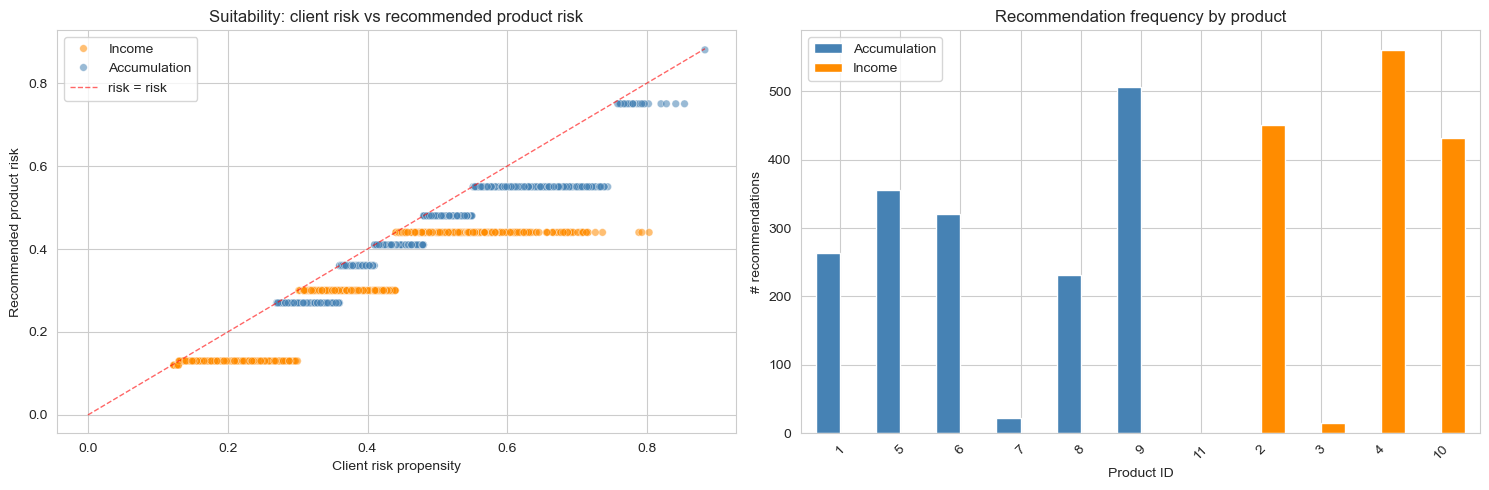


=== TOP-3 MOST RECOMMENDED (Accumulation) ===
  ProductID 9    | Risk 0.270 | recommended to 506 clients
  ProductID 5    | Risk 0.410 | recommended to 356 clients
  ProductID 6    | Risk 0.360 | recommended to 321 clients

=== TOP-3 MOST RECOMMENDED (Income) ===
  ProductID 4    | Risk 0.440 | recommended to 561 clients
  ProductID 2    | Risk 0.300 | recommended to 451 clients
  ProductID 10   | Risk 0.130 | recommended to 432 clients

Saved -> artifacts/recommendations.csv


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Product catalogue, split by type
products_df     = pd.read_excel('Dataset2_Needs.xls', sheet_name='Products')
accum_products  = products_df[products_df['Type'] == 1].reset_index(drop=True)
income_products = products_df[products_df['Type'] == 0].reset_index(drop=True)

print(f"Catalogue: {len(accum_products)} accumulation / {len(income_products)} income")

# Score every client (pure inference, no refitting)
X_full = df_engineered[feature_cols].copy()
X_full[FAT_TAIL_FEATURES] = qt.transform(X_full[FAT_TAIL_FEATURES])
std_cols = [c for c in feature_cols if c not in FAT_TAIL_FEATURES]
X_full[std_cols] = rs.transform(X_full[std_cols])

model.eval()
with torch.no_grad():
    Xt = torch.tensor(X_full.values, dtype=torch.float32)
    la, li = model(Xt)
    p_acc_all = cal_acc(torch.sigmoid(la).numpy())
    p_inc_all = cal_inc(torch.sigmoid(li).numpy())

need_acc = p_acc_all >= thr_acc
need_inc = p_inc_all >= thr_inc
client_risks = df_engineered['RiskPropensity'].values

print(f"\nNeed Accumulation: {need_acc.sum():>5} clients ({need_acc.mean()*100:.1f}%)")
print(f"Need Income      : {need_inc.sum():>5} clients ({need_inc.mean()*100:.1f}%)")


def match_best_product(client_risk, catalogue):
    '''Highest-risk product still compliant with the client's tolerance.
       Returns (id, risk) or (None, None) if no product fits (catalogue gap).'''
    eligible = catalogue[catalogue['Risk'] <= client_risk + 1e-9]
    if eligible.empty:
        return None, None
    best = eligible.loc[eligible['Risk'].idxmax()]
    return int(best['IDProduct']), float(best['Risk'])


rows = []
for i in range(len(df_engineered)):
    cr = client_risks[i]
    rec_a = match_best_product(cr, accum_products)  if need_acc[i] else (None, None)
    rec_i = match_best_product(cr, income_products) if need_inc[i] else (None, None)
    rows.append({
        'ClientID':        i + 1,
        'ClientRisk':      round(cr, 4),
        'P_Accum':         round(float(p_acc_all[i]), 4),
        'P_Income':        round(float(p_inc_all[i]), 4),
        'NeedAccum':       bool(need_acc[i]),
        'NeedIncome':      bool(need_inc[i]),
        'Rec_Accum_ID':    rec_a[0], 'Rec_Accum_Risk':  rec_a[1],
        'Rec_Income_ID':   rec_i[0], 'Rec_Income_Risk': rec_i[1],
    })
nba = pd.DataFrame(rows)

print("\nFirst 10 recommendations:")
display(nba.head(10))

# Coverage decomposition: split clients without a recommendation into
# "correct silence" (model said no need) vs "catalogue gap" (need flagged,
# no compliant product). The second bucket is a product-line signal, not a
# model failure.
covered_acc = nba['Rec_Accum_ID'].notna()
covered_inc = nba['Rec_Income_ID'].notna()
covered_any = covered_acc | covered_inc

gap_acc = nba['NeedAccum']  & ~covered_acc
gap_inc = nba['NeedIncome'] & ~covered_inc
silent  = ~nba['NeedAccum'] & ~nba['NeedIncome']

summary = pd.DataFrame({
    'Segment': ['No need predicted (correct silence)',
                'At least one recommendation emitted',
                'Accumulation gap (need flagged, no compliant product)',
                'Income       gap (need flagged, no compliant product)'],
    'Clients': [int(silent.sum()),    int(covered_any.sum()),
                int(gap_acc.sum()),   int(gap_inc.sum())],
    'Pct (%)': [round(silent.mean()*100, 1),   round(covered_any.mean()*100, 1),
                round(gap_acc.mean()*100, 1),  round(gap_inc.mean()*100, 1)],
})
print("\n=== COVERAGE DECOMPOSITION ===")
print(summary.to_string(index=False))

# Diagnostic plots: suitability scatter + recommendation frequency
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

vis = nba[covered_any].copy()
vis['PickedRisk'] = vis['Rec_Accum_Risk'].fillna(vis['Rec_Income_Risk'])
vis['Head']       = np.where(vis['Rec_Accum_ID'].notna(), 'Accumulation', 'Income')

sns.scatterplot(ax=axes[0], data=vis, x='ClientRisk', y='PickedRisk',
                hue='Head', alpha=0.55, s=30,
                palette={'Accumulation': 'steelblue', 'Income': 'darkorange'})
max_r = float(max(vis['ClientRisk'].max(), vis['PickedRisk'].max()))
axes[0].plot([0, max_r], [0, max_r], 'r--', lw=1, alpha=0.6, label='risk = risk')
axes[0].set_title('Suitability: client risk vs recommended product risk')
axes[0].set_xlabel('Client risk propensity')
axes[0].set_ylabel('Recommended product risk')
axes[0].legend()

freq_acc = nba['Rec_Accum_ID'].dropna().astype(int).value_counts().sort_index()
freq_inc = nba['Rec_Income_ID'].dropna().astype(int).value_counts().sort_index()
freq = (pd.concat([freq_acc.rename('Accumulation'),
                   freq_inc.rename('Income')], axis=1)
          .fillna(0).astype(int))
freq.plot(kind='bar', ax=axes[1], color=['steelblue', 'darkorange'], width=0.8)
axes[1].set_title('Recommendation frequency by product')
axes[1].set_xlabel('Product ID')
axes[1].set_ylabel('# recommendations')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


def print_top(freq_series, title, k=3):
    print(f"\n=== {title} ===")
    if freq_series.empty:
        print("  (no recommendations emitted)")
        return
    for pid in freq_series.nlargest(k).index:
        pr = products_df.loc[products_df['IDProduct'] == pid, 'Risk'].iloc[0]
        print(f"  ProductID {pid:<4} | Risk {pr:.3f} | "
              f"recommended to {int(freq_series[pid])} clients")

print_top(freq_acc, "TOP-3 MOST RECOMMENDED (Accumulation)")
print_top(freq_inc, "TOP-3 MOST RECOMMENDED (Income)")

nba.to_csv('artifacts/recommendations.csv', index=False)
print("\nSaved -> artifacts/recommendations.csv")


## Cross-model comparison on the shared test set

All three notebooks (Decision Tree, Random Forest, Multi-Task NN) use the
same `random_state=42`, `test_size=0.20`, and joint-stratification key, so
the 1 000 test rows are identical across models. Each notebook exports its
calibrated test-set probabilities to `compare_preds/`; this cell loads the
six arrays and builds the unified table + curves used in the final report.


All models evaluated on 1000 shared test clients.

UNIFIED TEST-SET COMPARISON (all models, same clients, same labels)
        Model  ROC-AUC Accum  PR-AUC  Accum  Brier   Accum  F1@thr  Accum  ROC-AUC Income  PR-AUC  Income  Brier   Income  F1@thr  Income
Decision Tree         0.8825         0.9113         0.1225         0.8423          0.8120          0.8148          0.1479          0.7395
Random Forest         0.8759         0.9130         0.1187         0.8383          0.7956          0.8064          0.1458          0.7333
Multi-Task NN         0.8504         0.8911         0.1486         0.7891          0.7926          0.7856          0.1589          0.6932

Brier: lower = better calibrated.  F1@thr uses each model's own optimal threshold.


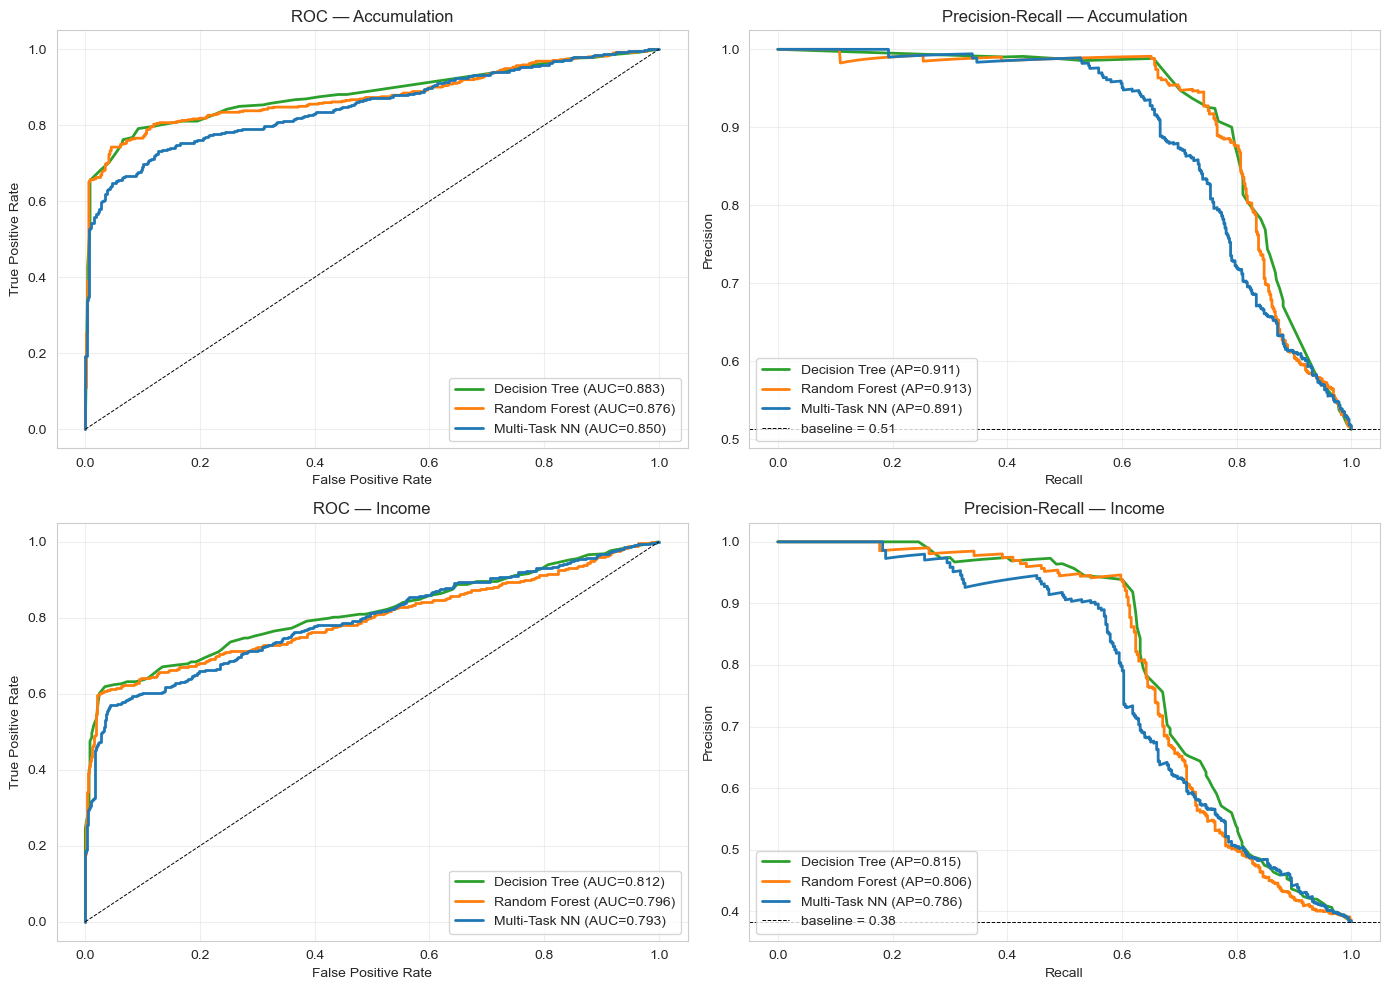

Saved -> compare_preds/comparison_table.csv + comparison_curves.png


In [25]:
from sklearn.metrics import (roc_curve, precision_recall_curve,
                             f1_score, brier_score_loss)

y_acc = np.load('compare_preds/y_acc_test.npy')
y_inc = np.load('compare_preds/y_inc_test.npy')

preds = {
    'Decision Tree': {'acc': np.load('compare_preds/dt_p_acc_test.npy'),
                      'inc': np.load('compare_preds/dt_p_inc_test.npy')},
    'Random Forest': {'acc': np.load('compare_preds/rf_p_acc_test.npy'),
                      'inc': np.load('compare_preds/rf_p_inc_test.npy')},
    'Multi-Task NN': {'acc': np.load('compare_preds/mtl_p_acc_test.npy'),
                      'inc': np.load('compare_preds/mtl_p_inc_test.npy')},
}

# All predictions must be on the same number of rows; sanity-check that.
for name, p in preds.items():
    assert len(p['acc']) == len(y_acc), f"{name}: accum length mismatch"
    assert len(p['inc']) == len(y_inc), f"{name}: income length mismatch"
print(f"All models evaluated on {len(y_acc)} shared test clients.\n")


def best_f1(y, p, grid=np.linspace(0.05, 0.95, 181)):
    '''Model-specific F1-optimal threshold -- fair to each model.'''
    scores = [f1_score(y, p > t) for t in grid]
    i = int(np.argmax(scores))
    return float(grid[i]), float(scores[i])


rows = []
for name, p in preds.items():
    _, f1_a = best_f1(y_acc, p['acc'])
    _, f1_i = best_f1(y_inc, p['inc'])
    rows.append({
        'Model':          name,
        'ROC-AUC Accum':  round(roc_auc_score(y_acc, p['acc']), 4),
        'PR-AUC  Accum':  round(average_precision_score(y_acc, p['acc']), 4),
        'Brier   Accum':  round(brier_score_loss(y_acc, p['acc']), 4),
        'F1@thr  Accum':  round(f1_a, 4),
        'ROC-AUC Income': round(roc_auc_score(y_inc, p['inc']), 4),
        'PR-AUC  Income': round(average_precision_score(y_inc, p['inc']), 4),
        'Brier   Income': round(brier_score_loss(y_inc, p['inc']), 4),
        'F1@thr  Income': round(f1_i, 4),
    })
cmp_df = pd.DataFrame(rows)

print("=" * 90)
print("UNIFIED TEST-SET COMPARISON (all models, same clients, same labels)")
print("=" * 90)
print(cmp_df.to_string(index=False))
print("\nBrier: lower = better calibrated.  F1@thr uses each model's own optimal threshold.")

cmp_df.to_csv('compare_preds/comparison_table.csv', index=False)

# ROC + PR per head, one row per head, one column per curve type
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = {'Decision Tree': 'tab:green',
          'Random Forest': 'tab:orange',
          'Multi-Task NN': 'tab:blue'}

for row, head in enumerate(['acc', 'inc']):
    y = y_acc if head == 'acc' else y_inc
    head_name = 'Accumulation' if head == 'acc' else 'Income'

    for name, p in preds.items():
        fpr, tpr, _ = roc_curve(y, p[head])
        axes[row, 0].plot(fpr, tpr, color=colors[name], lw=2,
                          label=f'{name} (AUC={roc_auc_score(y, p[head]):.3f})')
        pr, rc, _ = precision_recall_curve(y, p[head])
        axes[row, 1].plot(rc, pr, color=colors[name], lw=2,
                          label=f'{name} (AP={average_precision_score(y, p[head]):.3f})')

    axes[row, 0].plot([0, 1], [0, 1], 'k--', lw=0.7)
    axes[row, 0].set_title(f'ROC — {head_name}')
    axes[row, 0].set_xlabel('False Positive Rate')
    axes[row, 0].set_ylabel('True Positive Rate')
    axes[row, 0].legend(loc='lower right')
    axes[row, 0].grid(alpha=0.3)

    axes[row, 1].axhline(y.mean(), color='k', ls='--', lw=0.7,
                         label=f'baseline = {y.mean():.2f}')
    axes[row, 1].set_title(f'Precision-Recall — {head_name}')
    axes[row, 1].set_xlabel('Recall')
    axes[row, 1].set_ylabel('Precision')
    axes[row, 1].legend(loc='lower left')
    axes[row, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('compare_preds/comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved -> compare_preds/comparison_table.csv + comparison_curves.png")
